#  Finishing Data preparation for model XGBoost — Respira SP

Este notebook é dedicado à finalização da preparação dos dados para o treinamento do modelo XGBoost no projeto Respira SP. A partir das bases pré-processadas, foram criadas features temporais, defasagens da série de PM2.5, rolling features e datasets supervisionados para diferentes estratégias de tratamento de dados Nan - Gaps.

## O que foi feito

- Definição do target de forecasting (target_24h)
- Criação de features temporais
- Criação de lags de PM2.5
- Criação de rolling features com shift(1) para evitar data leakage
- Montagem dos datasets supervisionados para cada estratégia de pré-processamento
- Remoção controlada de valores nulos apenas nas features e no target utilizados pelo modelo
- Salvamento dos datasets finais para treinamento em outro notebook.


## Observação

Esta versão utiliza a base histórica de ***2013 a 2019*** e mantém todas as features meteorológicas disponíveis:

- `temperature_2m`
- `relative_humidity_2m`
- `precipitation`
- `wind_speed_10m`

A ideia é comparar esta abordagem com o pré-processamento anterior do grupo, avaliando posteriormente qual estratégia gera melhor desempenho nos modelos.


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

In [27]:
# Importando as bases de dados 2013-2019
# Estrategia 1 sem imterpolação temporal / sazonal
df_estrategia01 = pd.read_csv("../data/data_sem_interpolacao/dados_2013_2019_sem_imputacao_all_features.csv")

In [6]:
# Estrategia 2 com imterpolação tempora em gaps menores 
df_estrategia02 = pd.read_csv("../data/data_interpolacao_gaps_menores/dados_2013_2019_interp_12h_all_features.csv")

In [7]:
# Estrategia 3 com imputação sazonal em gaps menores e imterpolação temporal em gaps menores
df_estrategia03 = pd.read_csv("../data/data_interpolacao_gaps_maiores_medias/pm25_2013_2019_interp_12h_media_sazonal_all_features.csv")

## 1. Definir target de forecasting

### Estrategia 1

In [28]:
df_estrategia01.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2013-05-09 03:00:00+00:00,26.0,10.301001,91.648320,0.0,7.421590
1,2013-05-09 04:00:00+00:00,21.0,9.751000,92.548310,0.0,7.993298
2,2013-05-09 05:00:00+00:00,20.0,9.401000,92.528390,0.0,7.928178
3,2013-05-09 06:00:00+00:00,18.0,9.251000,92.519806,0.0,7.280550
4,2013-05-09 07:00:00+00:00,20.0,9.851000,91.310250,0.0,6.287130


In [10]:
df_xgb_estrategia01 = df_estrategia01.copy()
df_xgb_estrategia01["target_24h"] = df_xgb_estrategia01["MP2.5"].shift(-24)

In [12]:
df_xgb_estrategia01[["MP2.5", "target_24h"]].head(10)

,MP2.5,target_24h
0,26.0,32.0
1,21.0,23.0
2,20.0,18.0
3,18.0,20.0
4,20.0,32.0
5,20.0,26.0
6,14.0,20.0
7,18.0,26.0
8,21.0,25.0
9,21.0,25.0


In [13]:
df_xgb_estrategia01["target_24h"].isna().sum()

3355

### Estrategia 2

In [15]:
df_xgb_estrategia02 = df_estrategia02.copy()
df_xgb_estrategia02["target_24h"] = df_xgb_estrategia02["MP2.5"].shift(-24)

In [16]:
df_xgb_estrategia02[["MP2.5", "target_24h"]].head(10)

,MP2.5,target_24h
0,26.0,32.0
1,21.0,23.0
2,20.0,18.0
3,18.0,20.0
4,20.0,32.0
5,20.0,26.0
6,14.0,20.0
7,18.0,26.0
8,21.0,25.0
9,21.0,25.0


In [17]:
df_xgb_estrategia02["target_24h"].isna().sum()

3049

### Estrategia 3

In [18]:
df_xgb_estrategia03 = df_estrategia03.copy()
df_xgb_estrategia03["target_24h"] = df_xgb_estrategia03["MP2.5"].shift(-24)

In [19]:
df_xgb_estrategia03[["MP2.5", "target_24h"]].head(10)

,MP2.5,target_24h
0,26.0,32.0
1,21.0,23.0
2,20.0,18.0
3,18.0,20.0
4,20.0,32.0
5,20.0,26.0
6,14.0,20.0
7,18.0,26.0
8,21.0,25.0
9,21.0,25.0


In [20]:
df_xgb_estrategia02["target_24h"].isna().sum()

3049

## 2.Features Temporais

In [21]:
df_xgb_estrategia03.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,mes,hora,dia_semana,MP2.5_imputado_media,target_24h
0,2013-05-09 03:00:00+00:00,26.0,10.301001,91.648320,0.0,7.421590,5,3,3,0,32.0
1,2013-05-09 04:00:00+00:00,21.0,9.751000,92.548310,0.0,7.993298,5,4,3,0,23.0
2,2013-05-09 05:00:00+00:00,20.0,9.401000,92.528390,0.0,7.928178,5,5,3,0,18.0
3,2013-05-09 06:00:00+00:00,18.0,9.251000,92.519806,0.0,7.280550,5,6,3,0,20.0
4,2013-05-09 07:00:00+00:00,20.0,9.851000,91.310250,0.0,6.287130,5,7,3,0,32.0


### Estrategia 3 já possui as features temporais... basta agora criar as mesmas para estrategia 1 e 2

In [31]:
df_xgb_estrategia01["time"] = pd.to_datetime(df_xgb_estrategia01["time"])

df_xgb_estrategia01["mes"] = df_xgb_estrategia01["time"].dt.month
df_xgb_estrategia01["hora"] = df_xgb_estrategia01["time"].dt.hour
df_xgb_estrategia01["dia_semana"] = df_xgb_estrategia01["time"].dt.dayofweek

In [33]:
df_xgb_estrategia01.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,target_24h,mes,hora,dia_semana
0,2013-05-09 03:00:00+00:00,26.0,10.301001,91.648320,0.0,7.421590,32.0,5,3,3
1,2013-05-09 04:00:00+00:00,21.0,9.751000,92.548310,0.0,7.993298,23.0,5,4,3
2,2013-05-09 05:00:00+00:00,20.0,9.401000,92.528390,0.0,7.928178,18.0,5,5,3
3,2013-05-09 06:00:00+00:00,18.0,9.251000,92.519806,0.0,7.280550,20.0,5,6,3
4,2013-05-09 07:00:00+00:00,20.0,9.851000,91.310250,0.0,6.287130,32.0,5,7,3


In [34]:
df_xgb_estrategia02["time"] = pd.to_datetime(df_xgb_estrategia02["time"])

df_xgb_estrategia02["mes"] = df_xgb_estrategia02["time"].dt.month
df_xgb_estrategia02["hora"] = df_xgb_estrategia02["time"].dt.hour
df_xgb_estrategia02["dia_semana"] = df_xgb_estrategia02["time"].dt.dayofweek
df_xgb_estrategia02.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,target_24h,mes,hora,dia_semana
0,2013-05-09 03:00:00+00:00,26.0,10.301001,91.648320,0.0,7.421590,32.0,5,3,3
1,2013-05-09 04:00:00+00:00,21.0,9.751000,92.548310,0.0,7.993298,23.0,5,4,3
2,2013-05-09 05:00:00+00:00,20.0,9.401000,92.528390,0.0,7.928178,18.0,5,5,3
3,2013-05-09 06:00:00+00:00,18.0,9.251000,92.519806,0.0,7.280550,20.0,5,6,3
4,2013-05-09 07:00:00+00:00,20.0,9.851000,91.310250,0.0,6.287130,32.0,5,7,3


## 3.Criar lags de PM2.5

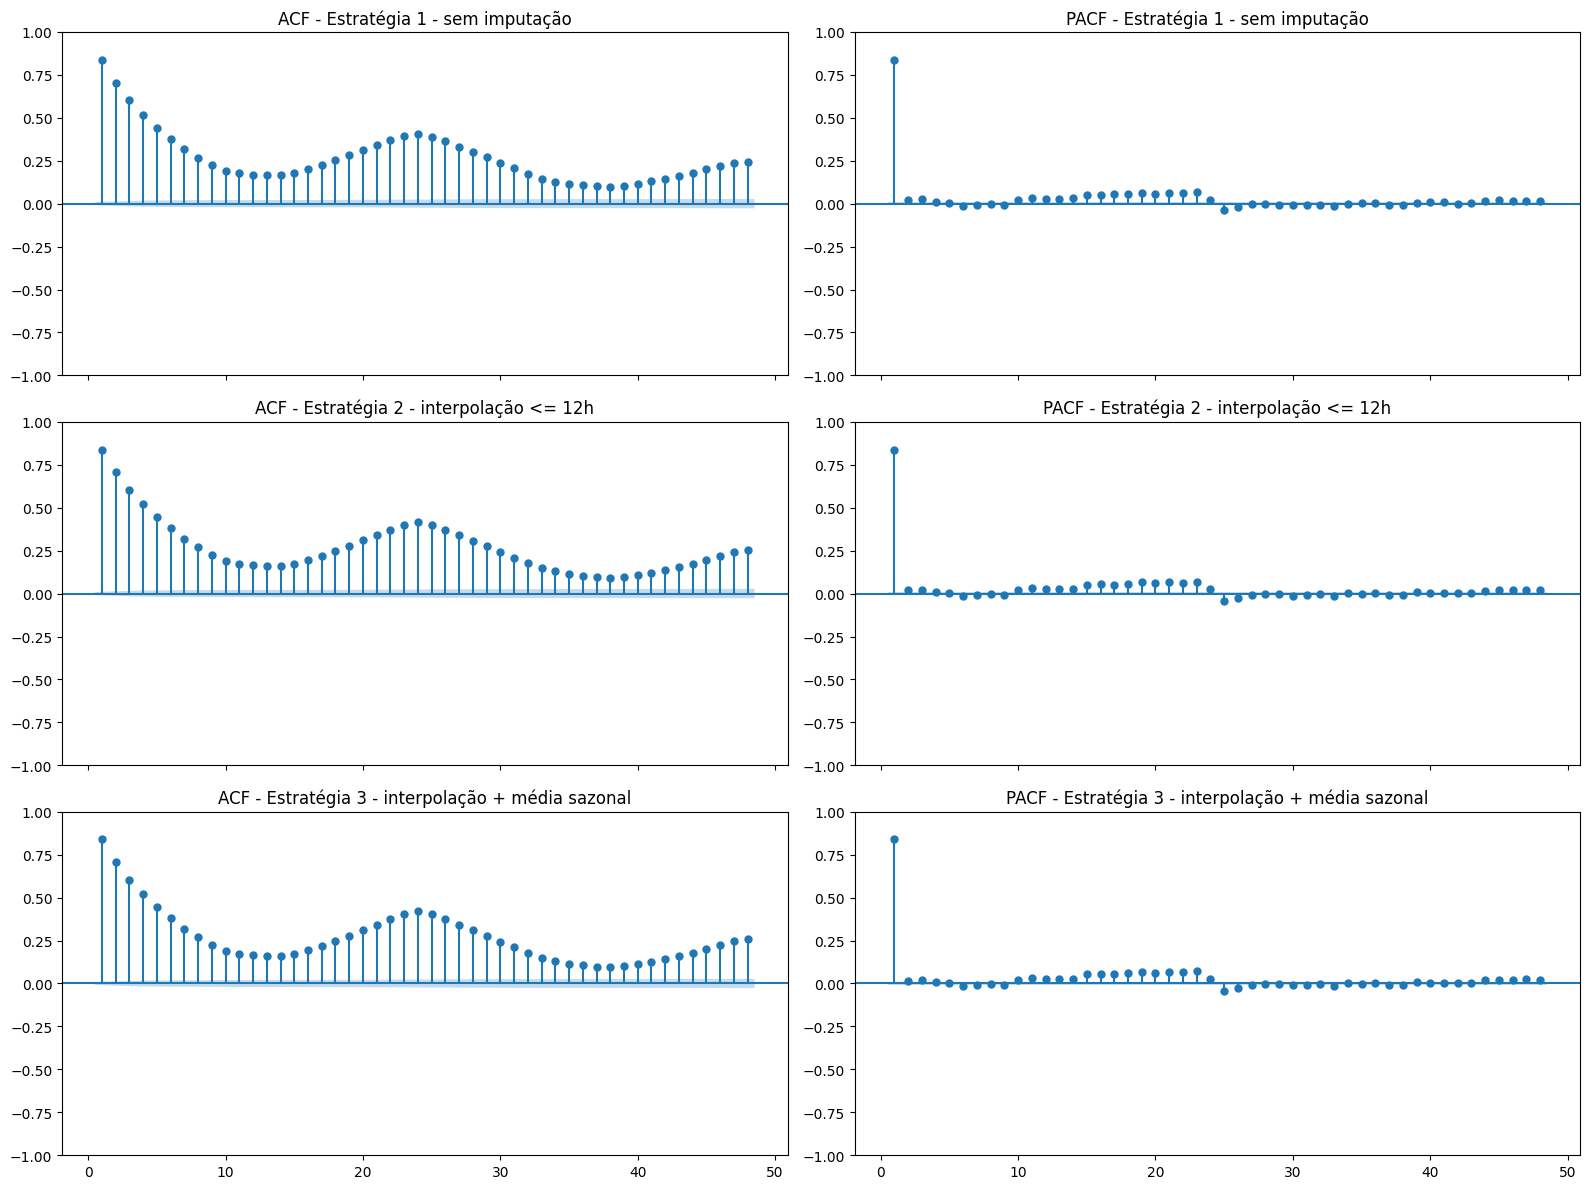

In [37]:
dfs = {
    "Estratégia 1 - sem imputação": df_xgb_estrategia01,
    "Estratégia 2 - interpolação <= 12h": df_xgb_estrategia02,
    "Estratégia 3 - interpolação + média sazonal": df_xgb_estrategia03,
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 12),
    sharex=True
)

for i, (nome, data) in enumerate(dfs.items()):
    serie = data["MP2.5"].dropna()

    plot_acf(
        serie,
        lags=48,
        ax=axes[i, 0],
        zero=False
    )

    axes[i, 0].set_title(f"ACF - {nome}")

    plot_pacf(
        serie,
        lags=48,
        ax=axes[i, 1],
        method="ywm",
        zero=False
    )

    axes[i, 1].set_title(f"PACF - {nome}")

plt.tight_layout()
plt.show()

### Nas três estratégias, o ACF tem autocorrelação alta nos primeiros lags e vai caindo gradualmente, parece ter dependência temporal forte.
### O PACF tem um pico muito forte no lag_1, e depois os valores ficam bem menores

In [38]:
# Estrategia 3 fazendo os lags
lags = [1, 3, 6, 12, 24]
for lag in lags:
    df_xgb_estrategia03[f"PM2.5_lag_{lag}h"] = df_xgb_estrategia03["MP2.5"].shift(lag)

In [39]:
df_xgb_estrategia03.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,mes,hora,dia_semana,MP2.5_imputado_media,target_24h,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h
0,2013-05-09 03:00:00+00:00,26.0,10.301001,91.648320,0.0,7.421590,5,3,3,0,32.0,NaN,NaN,NaN,NaN,NaN
1,2013-05-09 04:00:00+00:00,21.0,9.751000,92.548310,0.0,7.993298,5,4,3,0,23.0,26.0,NaN,NaN,NaN,NaN
2,2013-05-09 05:00:00+00:00,20.0,9.401000,92.528390,0.0,7.928178,5,5,3,0,18.0,21.0,NaN,NaN,NaN,NaN
3,2013-05-09 06:00:00+00:00,18.0,9.251000,92.519806,0.0,7.280550,5,6,3,0,20.0,20.0,26.0,NaN,NaN,NaN
4,2013-05-09 07:00:00+00:00,20.0,9.851000,91.310250,0.0,6.287130,5,7,3,0,32.0,18.0,21.0,NaN,NaN,NaN


In [40]:
# Estrategia 2 fazendo os lags
lags = [1, 3, 6, 12, 24]
for lag in lags:
    df_xgb_estrategia02[f"PM2.5_lag_{lag}h"] = df_xgb_estrategia02["MP2.5"].shift(lag)

In [41]:
df_xgb_estrategia02.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,target_24h,mes,hora,dia_semana,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h
0,2013-05-09 03:00:00+00:00,26.0,10.301001,91.648320,0.0,7.421590,32.0,5,3,3,NaN,NaN,NaN,NaN,NaN
1,2013-05-09 04:00:00+00:00,21.0,9.751000,92.548310,0.0,7.993298,23.0,5,4,3,26.0,NaN,NaN,NaN,NaN
2,2013-05-09 05:00:00+00:00,20.0,9.401000,92.528390,0.0,7.928178,18.0,5,5,3,21.0,NaN,NaN,NaN,NaN
3,2013-05-09 06:00:00+00:00,18.0,9.251000,92.519806,0.0,7.280550,20.0,5,6,3,20.0,26.0,NaN,NaN,NaN
4,2013-05-09 07:00:00+00:00,20.0,9.851000,91.310250,0.0,6.287130,32.0,5,7,3,18.0,21.0,NaN,NaN,NaN


In [44]:
# Estrategia 1 fazendo os lags
lags = [1, 3, 6, 12, 24]
for lag in lags:
    df_xgb_estrategia01[f"PM2.5_lag_{lag}h"] = df_xgb_estrategia01["MP2.5"].shift(lag)

In [45]:
df_xgb_estrategia01.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,target_24h,mes,hora,dia_semana,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h
0,2013-05-09 03:00:00+00:00,26.0,10.301001,91.648320,0.0,7.421590,32.0,5,3,3,NaN,NaN,NaN,NaN,NaN
1,2013-05-09 04:00:00+00:00,21.0,9.751000,92.548310,0.0,7.993298,23.0,5,4,3,26.0,NaN,NaN,NaN,NaN
2,2013-05-09 05:00:00+00:00,20.0,9.401000,92.528390,0.0,7.928178,18.0,5,5,3,21.0,NaN,NaN,NaN,NaN
3,2013-05-09 06:00:00+00:00,18.0,9.251000,92.519806,0.0,7.280550,20.0,5,6,3,20.0,26.0,NaN,NaN,NaN
4,2013-05-09 07:00:00+00:00,20.0,9.851000,91.310250,0.0,6.287130,32.0,5,7,3,18.0,21.0,NaN,NaN,NaN


## 4. Criar rolling features

In [49]:
#Estrategia 1 - rolling features
rolling_windows = [3, 6, 12, 24]

for window in rolling_windows:
    df_xgb_estrategia01[f"PM2.5_rolling_mean_{window}h"] = (
        df_xgb_estrategia01["MP2.5"]
        .shift(1)
        .rolling(window=window)
        .mean()
    )

df_xgb_estrategia01["PM2.5_rolling_std_24h"] = (
    df_xgb_estrategia01["MP2.5"]
    .shift(1)
    .rolling(window=24)
    .std()
)

In [50]:
df_xgb_estrategia01[["MP2.5",
        "PM2.5_rolling_mean_3h",
        "PM2.5_rolling_mean_6h",
        "PM2.5_rolling_mean_12h",
        "PM2.5_rolling_mean_24h",
        "PM2.5_rolling_std_24h"]].head(20)

,MP2.5,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,26.0,NaN,NaN,NaN,NaN,NaN
1,21.0,NaN,NaN,NaN,NaN,NaN
2,20.0,NaN,NaN,NaN,NaN,NaN
3,18.0,22.333333,NaN,NaN,NaN,NaN
4,20.0,19.666667,NaN,NaN,NaN,NaN
5,20.0,19.333333,NaN,NaN,NaN,NaN
6,14.0,19.333333,20.833333,NaN,NaN,NaN
7,18.0,18.000000,18.833333,NaN,NaN,NaN
8,21.0,17.333333,18.333333,NaN,NaN,NaN
9,21.0,17.666667,18.500000,NaN,NaN,NaN


In [51]:
#Estrategia 2 - rolling features
rolling_windows = [3, 6, 12, 24]

for window in rolling_windows:
    df_xgb_estrategia02[f"PM2.5_rolling_mean_{window}h"] = (
        df_xgb_estrategia02["MP2.5"]
        .shift(1)
        .rolling(window=window)
        .mean()
    )

df_xgb_estrategia02["PM2.5_rolling_std_24h"] = (
    df_xgb_estrategia02["MP2.5"]
    .shift(1)
    .rolling(window=24)
    .std()
)

In [52]:
df_xgb_estrategia02[["MP2.5",
        "PM2.5_rolling_mean_3h",
        "PM2.5_rolling_mean_6h",
        "PM2.5_rolling_mean_12h",
        "PM2.5_rolling_mean_24h",
        "PM2.5_rolling_std_24h"]].head(20)

,MP2.5,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,26.0,NaN,NaN,NaN,NaN,NaN
1,21.0,NaN,NaN,NaN,NaN,NaN
2,20.0,NaN,NaN,NaN,NaN,NaN
3,18.0,22.333333,NaN,NaN,NaN,NaN
4,20.0,19.666667,NaN,NaN,NaN,NaN
5,20.0,19.333333,NaN,NaN,NaN,NaN
6,14.0,19.333333,20.833333,NaN,NaN,NaN
7,18.0,18.000000,18.833333,NaN,NaN,NaN
8,21.0,17.333333,18.333333,NaN,NaN,NaN
9,21.0,17.666667,18.500000,NaN,NaN,NaN


In [53]:
#Estrategia 3 - rolling features
rolling_windows = [3, 6, 12, 24]

for window in rolling_windows:
    df_xgb_estrategia03[f"PM2.5_rolling_mean_{window}h"] = (
        df_xgb_estrategia03["MP2.5"]
        .shift(1)
        .rolling(window=window)
        .mean()
    )

df_xgb_estrategia03["PM2.5_rolling_std_24h"] = (
    df_xgb_estrategia03["MP2.5"]
    .shift(1)
    .rolling(window=24)
    .std()
)

In [54]:
df_xgb_estrategia03[["MP2.5",
        "PM2.5_rolling_mean_3h",
        "PM2.5_rolling_mean_6h",
        "PM2.5_rolling_mean_12h",
        "PM2.5_rolling_mean_24h",
        "PM2.5_rolling_std_24h"]].head(20)

,MP2.5,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,26.0,NaN,NaN,NaN,NaN,NaN
1,21.0,NaN,NaN,NaN,NaN,NaN
2,20.0,NaN,NaN,NaN,NaN,NaN
3,18.0,22.333333,NaN,NaN,NaN,NaN
4,20.0,19.666667,NaN,NaN,NaN,NaN
5,20.0,19.333333,NaN,NaN,NaN,NaN
6,14.0,19.333333,20.833333,NaN,NaN,NaN
7,18.0,18.000000,18.833333,NaN,NaN,NaN
8,21.0,17.333333,18.333333,NaN,NaN,NaN
9,21.0,17.666667,18.500000,NaN,NaN,NaN


### mean e std são duas informações diferentes sobre a janela de tempo, mean vai trazer média movel respondendo: “Qual foi o nível médio de PM2.5 nas últimas X horas?” e std é o desvio padrão móvel, ele responde: “O PM2.5 ficou estável ou variou muito nas últimas X horas?”


## 5. Montar dataset supervisionado

In [55]:
features = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "mes",
    "hora",
    "dia_semana",
    "PM2.5_lag_1h",
    "PM2.5_lag_3h",
    "PM2.5_lag_6h",
    "PM2.5_lag_12h",
    "PM2.5_lag_24h",
    "PM2.5_rolling_mean_3h",
    "PM2.5_rolling_mean_6h",
    "PM2.5_rolling_mean_12h",
    "PM2.5_rolling_mean_24h",
    "PM2.5_rolling_std_24h"
]

target = "target_24h"

df_xgb_estrategia01_model = df_xgb_estrategia01.dropna(
    subset=features + [target]
).copy()

In [56]:
df_xgb_estrategia02_model = df_xgb_estrategia02.dropna(
    subset=features + [target]
).copy()

In [57]:
df_xgb_estrategia03_model = df_xgb_estrategia03.dropna(
    subset=features + [target]
).copy()

In [58]:
print(df_xgb_estrategia01.shape)
print(df_xgb_estrategia01_model.shape)

df_xgb_estrategia01_model.isna().sum()

(55008, 20)
(47275, 20)


time                        0
MP2.5                     107
temperature_2m              0
relative_humidity_2m        0
precipitation               0
wind_speed_10m              0
target_24h                  0
mes                         0
hora                        0
dia_semana                  0
PM2.5_lag_1h                0
PM2.5_lag_3h                0
PM2.5_lag_6h                0
PM2.5_lag_12h               0
PM2.5_lag_24h               0
PM2.5_rolling_mean_3h       0
PM2.5_rolling_mean_6h       0
PM2.5_rolling_mean_12h      0
PM2.5_rolling_mean_24h      0
PM2.5_rolling_std_24h       0
dtype: int64

In [59]:
print(df_xgb_estrategia02.shape)
print(df_xgb_estrategia02_model.shape)

df_xgb_estrategia02_model.isna().sum()

(55008, 20)
(50642, 20)


time                       0
MP2.5                     10
temperature_2m             0
relative_humidity_2m       0
precipitation              0
wind_speed_10m             0
target_24h                 0
mes                        0
hora                       0
dia_semana                 0
PM2.5_lag_1h               0
PM2.5_lag_3h               0
PM2.5_lag_6h               0
PM2.5_lag_12h              0
PM2.5_lag_24h              0
PM2.5_rolling_mean_3h      0
PM2.5_rolling_mean_6h      0
PM2.5_rolling_mean_12h     0
PM2.5_rolling_mean_24h     0
PM2.5_rolling_std_24h      0
dtype: int64

In [60]:
print(df_xgb_estrategia03.shape)
print(df_xgb_estrategia03_model.shape)

df_xgb_estrategia03_model.isna().sum()

(55008, 21)
(54960, 21)


time                      0
MP2.5                     0
temperature_2m            0
relative_humidity_2m      0
precipitation             0
wind_speed_10m            0
mes                       0
hora                      0
dia_semana                0
MP2.5_imputado_media      0
target_24h                0
PM2.5_lag_1h              0
PM2.5_lag_3h              0
PM2.5_lag_6h              0
PM2.5_lag_12h             0
PM2.5_lag_24h             0
PM2.5_rolling_mean_3h     0
PM2.5_rolling_mean_6h     0
PM2.5_rolling_mean_12h    0
PM2.5_rolling_mean_24h    0
PM2.5_rolling_std_24h     0
dtype: int64

### Salva os dfs

In [61]:
df_xgb_estrategia01_model.to_csv(
    "../data/processed_data/xgb_estrategia01_2013_2019_target_24h.csv",
    index=False
)

In [62]:
df_xgb_estrategia02_model.to_csv(
    "../data/processed_data/xgb_estrategia02_2013_2019_target_24h.csv",
    index=False
)

In [63]:
df_xgb_estrategia03_model.to_csv(
    "../data/processed_data/xgb_estrategia03_2013_2019_target_24h.csv",
    index=False
)